In [1]:
print("starting...")

starting...


In [2]:
pip install matplotlib

     ---------------------------------------- 0.0/111.1 kB ? eta -:--:--
     ---------- -------------------------- 30.7/111.1 kB 660.6 kB/s eta 0:00:01
     ------------- ----------------------- 41.0/111.1 kB 495.5 kB/s eta 0:00:01
     ------------------------------------ 111.1/111.1 kB 925.4 kB/s eta 0:00:00
     ---------------------------------------- 0.0/60.9 kB ? eta -:--:--
     ---------------------------------------- 60.9/60.9 kB 1.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.1 MB 2.6 MB/s eta 0:00:04
   - -------------------------------------- 0.2/8.1 MB 2.3 MB/s eta 0:00:04
   -- ------------------------------------- 0.4/8.1 MB 3.3 MB/s eta 0:00:03
   ---- ----------------------------------- 0.9/8.1 MB 5.0 MB/s eta 0:00:02
   ------ --------------------------------- 1.2/8.1 MB 6.1 MB/s eta 0:00:02
   --------- ------------------------------ 2.0/8.1 MB 7.9 MB/s eta 0:00:01
   -------


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\chele\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


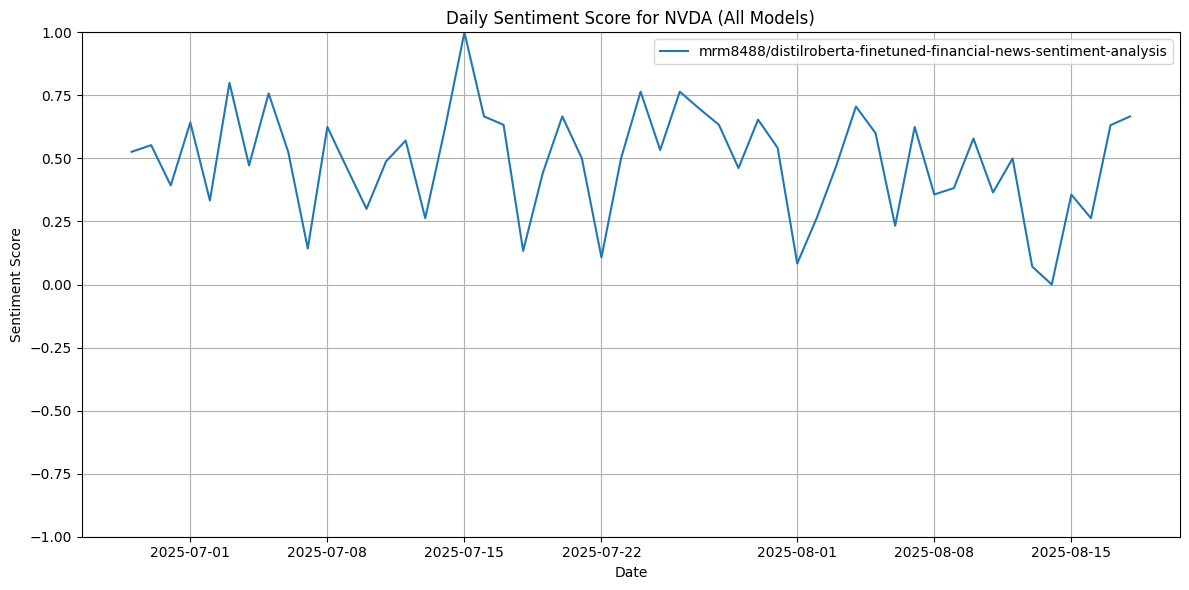

In [ ]:
# Add this cell to sentiment.ipynb to plot all models' daily sentiment curves

import os
import json
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from collections import defaultdict

stock_code = "NVDA"
base_dir = r"C:\git\daniel\stocks\scrapper\news"
models = [
    #"gpt-4.1",
    "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis",
    "meta-llama/Llama-3.2-3B-Instruct"
    #"deepseek-ai/deepseek-llm-7b-chat",
    #"mistralai/Mistral-7B-Instruct-v0.3"
]

def collect_daily_sentiment_for_stock(stock_code, base_dir, model_name):
    daily_scores = defaultdict(list)
    for date_folder in os.listdir(base_dir):
        date_path = os.path.join(base_dir, date_folder)
        if not os.path.isdir(date_path):
            continue
        news_file = os.path.join(date_path, stock_code, "detail", "news.json")
        if os.path.exists(news_file):
            with open(news_file, "r", encoding="utf-8") as f:
                news_items = json.load(f)
            for item in news_items:
                analysis = item.get("analysis", {})
                sentiment = analysis.get(model_name)
                if sentiment and isinstance(sentiment.get("value"), (int, float, str)):
                    try:
                        score = float(sentiment["value"])
                        daily_scores[date_folder].append(score)
                    except Exception:
                        continue
    result = []
    for date, scores in daily_scores.items():
        if scores:
            avg_score = np.mean(scores)
            result.append({"date": date, "score": avg_score})
    return sorted(result, key=lambda x: x["date"])

plt.figure(figsize=(12, 6))
for model_name in models:
    daily_sentiment = collect_daily_sentiment_for_stock(stock_code, base_dir, model_name)
    if daily_sentiment:
        dates = [datetime.strptime(x["date"], "%Y-%m-%d") for x in daily_sentiment]
        scores = [x["score"] for x in daily_sentiment]
        plt.plot(dates, scores, label=model_name)
plt.ylim(-1, 1)
plt.title(f"Daily Sentiment Score for {stock_code} (All Models)")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()